In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, f1_score, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.decomposition import PCA

In [2]:
# Load the dataset
df = pd.read_csv(r'DATA/ds_salaries.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


work_year: The year of employment.

experience_level: The experience level of the employee (e.g., entry-level, mid-level, senior).

employment_type: The type of employment (e.g., full-time, part-time, contract).

job_title: The job title or position of the employee within the company.

salary: The salary amount in the local currency.

salary_currency: The currency in which the salary is denoted.

salary_in_usd: The equivalent salary amount in USD (United States Dollars).

employee_residence: The location of the employee's residence.

remote_ratio: The percentage of remote work allowed for the position.

company_location: The location of the company.

company_size: The size of the company (e.g., small, medium, large).

In [3]:
# Check the structure of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [4]:
# Check for missing values
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [5]:
# Get summary statistics for numerical columns
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [6]:
# Check for duplicate rows
df[df.duplicated()].shape[0]

0

In [7]:
df['remote_ratio'].unique()

array([  0,  50, 100])

In [8]:
df['remote_ratio'] = df['remote_ratio']/100

In [9]:
# Analyze the average remote ratio by job title
temp=df.groupby('job_title')['remote_ratio'].mean().sort_values(ascending = False)
temp = temp.reset_index()
temp.style.background_gradient(cmap='Reds')

,job_title,remote_ratio
0,Data Architect,1.000000
1,Data Analytics Lead,1.000000
2,Computer Vision Software Engineer,1.000000
3,Principal Data Engineer,1.000000
4,Principal Data Analyst,1.000000
5,Marketing Data Analyst,1.000000
6,Staff Data Scientist,1.000000
7,Lead Data Analyst,1.000000
8,Data Specialist,1.000000
9,Director of Data Engineering,1.000000


In [10]:
# Visualize the average remote ratio by job title
fig = go.Figure()

fig.add_trace(
    go.Scatter(x = temp['job_title'], y = temp['remote_ratio'],
               name = "Confirmed",
               line_color = 'deepskyblue',
               opacity = 0.8               #gana line
               ))
fig.show()

In [11]:
#employees in the same residency as their company usually have Salary by 3259.9197166155063$
df[df['company_location'] == df['employee_residence']]['salary_in_usd'].mean() - df['salary_in_usd'].mean()

np.float64(3259.9197166155063)

In [12]:
#employees in the same residency as their company usually have remote ratio by 0.697841726618705
df[df['company_location'] == df['employee_residence']]['remote_ratio'].mean()

np.float64(0.697841726618705)

In [13]:
#employees in different residency as their company remote ratio by 0.83333333
df[df['company_location'] != df['employee_residence']]['remote_ratio'].mean()

np.float64(0.8333333333333334)

In [14]:
#employees work in different residency as their company usually have avreage Salary 3259.9197166155063$ more then average salary it work in saime residency of company
df[df['company_location'] != df['employee_residence']]['salary_in_usd'].mean() - df[df['company_location'] == df['employee_residence']]['salary_in_usd'].mean()

np.float64(-38799.43662716885)

In [15]:
#employees work in different residency as their company usually have avreage Salary 3259.9197166155063$ more than average salary in total 
df[df['company_location'] != df['employee_residence']]['salary_in_usd'].mean() - df['salary_in_usd'].mean()

np.float64(-35539.51691055334)

In [16]:
# employees in work not remote usually get less salary by -5943.247804485727$
df[df['remote_ratio'] < 0.50]['salary_in_usd'].mean() - df['salary_in_usd'].mean()

np.float64(-5943.247804485727)

<Axes: >

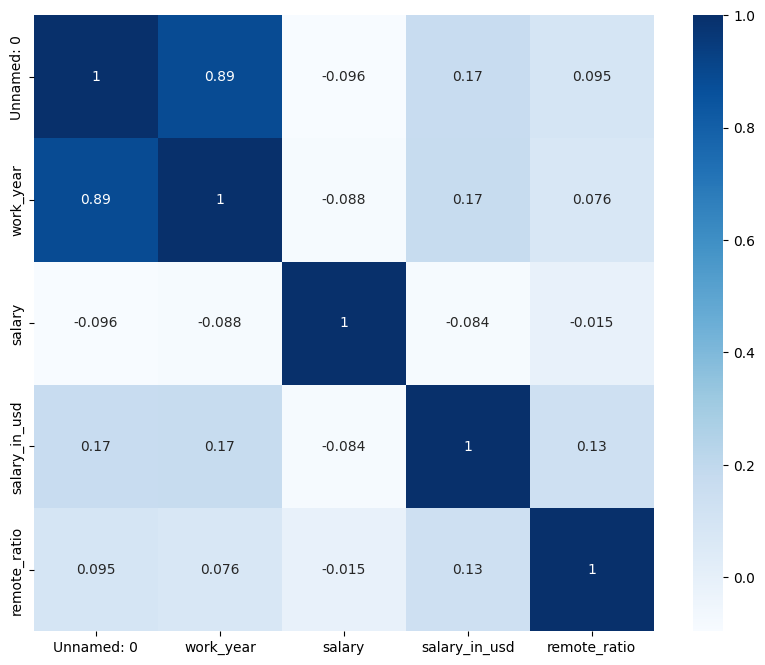

In [17]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap = 'Blues', annot = True)

In [18]:
df['company_size'].unique()

<StringArray>
['L', 'S', 'M']
Length: 3, dtype: str

<Axes: xlabel='salary_in_usd', ylabel='company_size'>

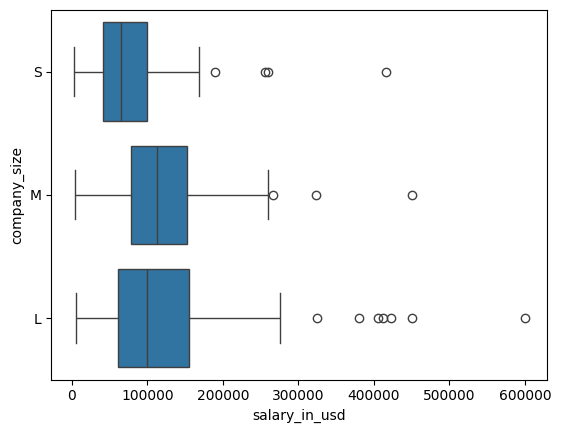

In [19]:
sns.boxplot(x=df['salary_in_usd'],
            y=df['company_size'],
            order=['S', 'M', 'L']
            )

In [20]:
# Remove outliers where salary_in_usd is greater than 300,000
df.drop(df[df['salary_in_usd']>300000].index, inplace = True)

Text(0.5, 1.0, 'top 15 paid jobs')

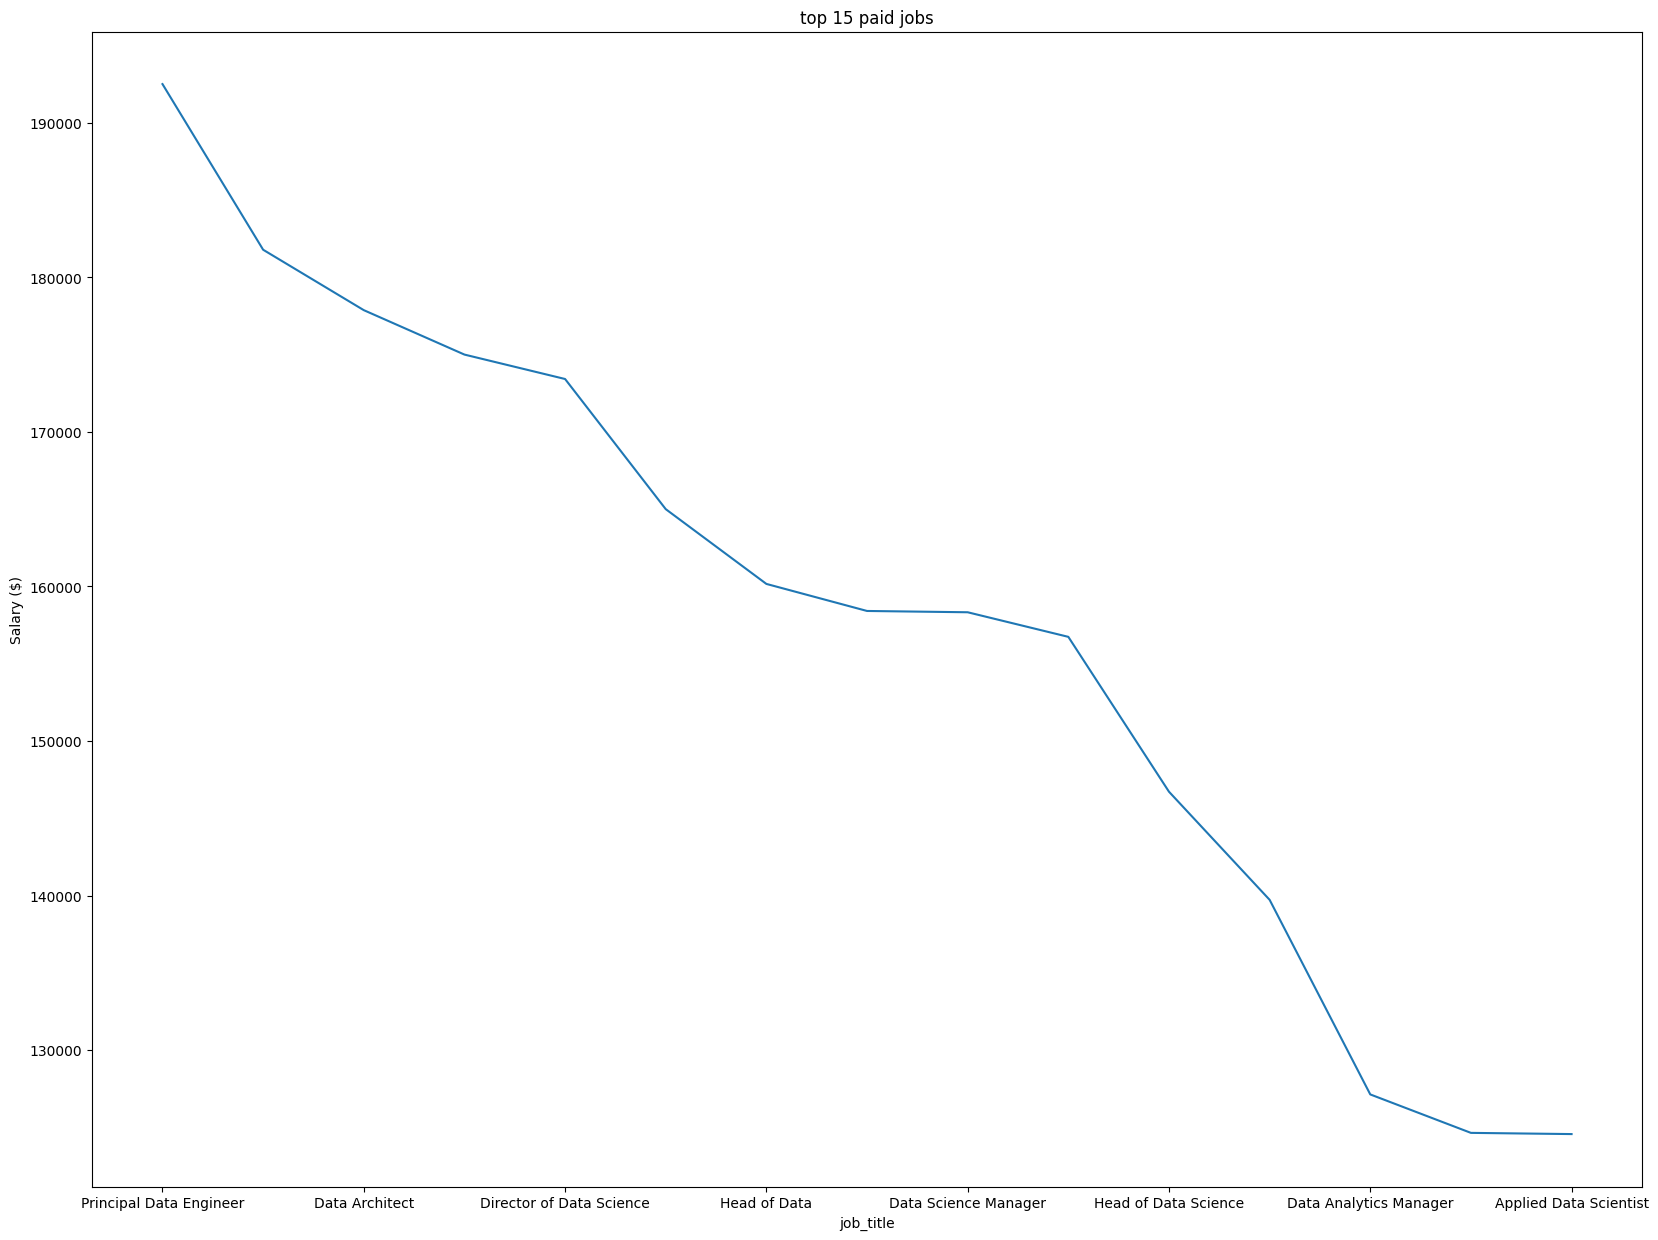

In [21]:
#top 15 paid jobs
plt.figure(figsize = (20, 15))
df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending = False).head(15).plot.line()
plt.ylabel('Salary ($)')
plt.title('top 15 paid jobs')

In [22]:
df['work_year'].unique()

array([2020, 2021, 2022])

Text(0.5, 1.0, 'least 15 paid jobs in 2020 (red), 2021 (yellow) and 2022 (green)')

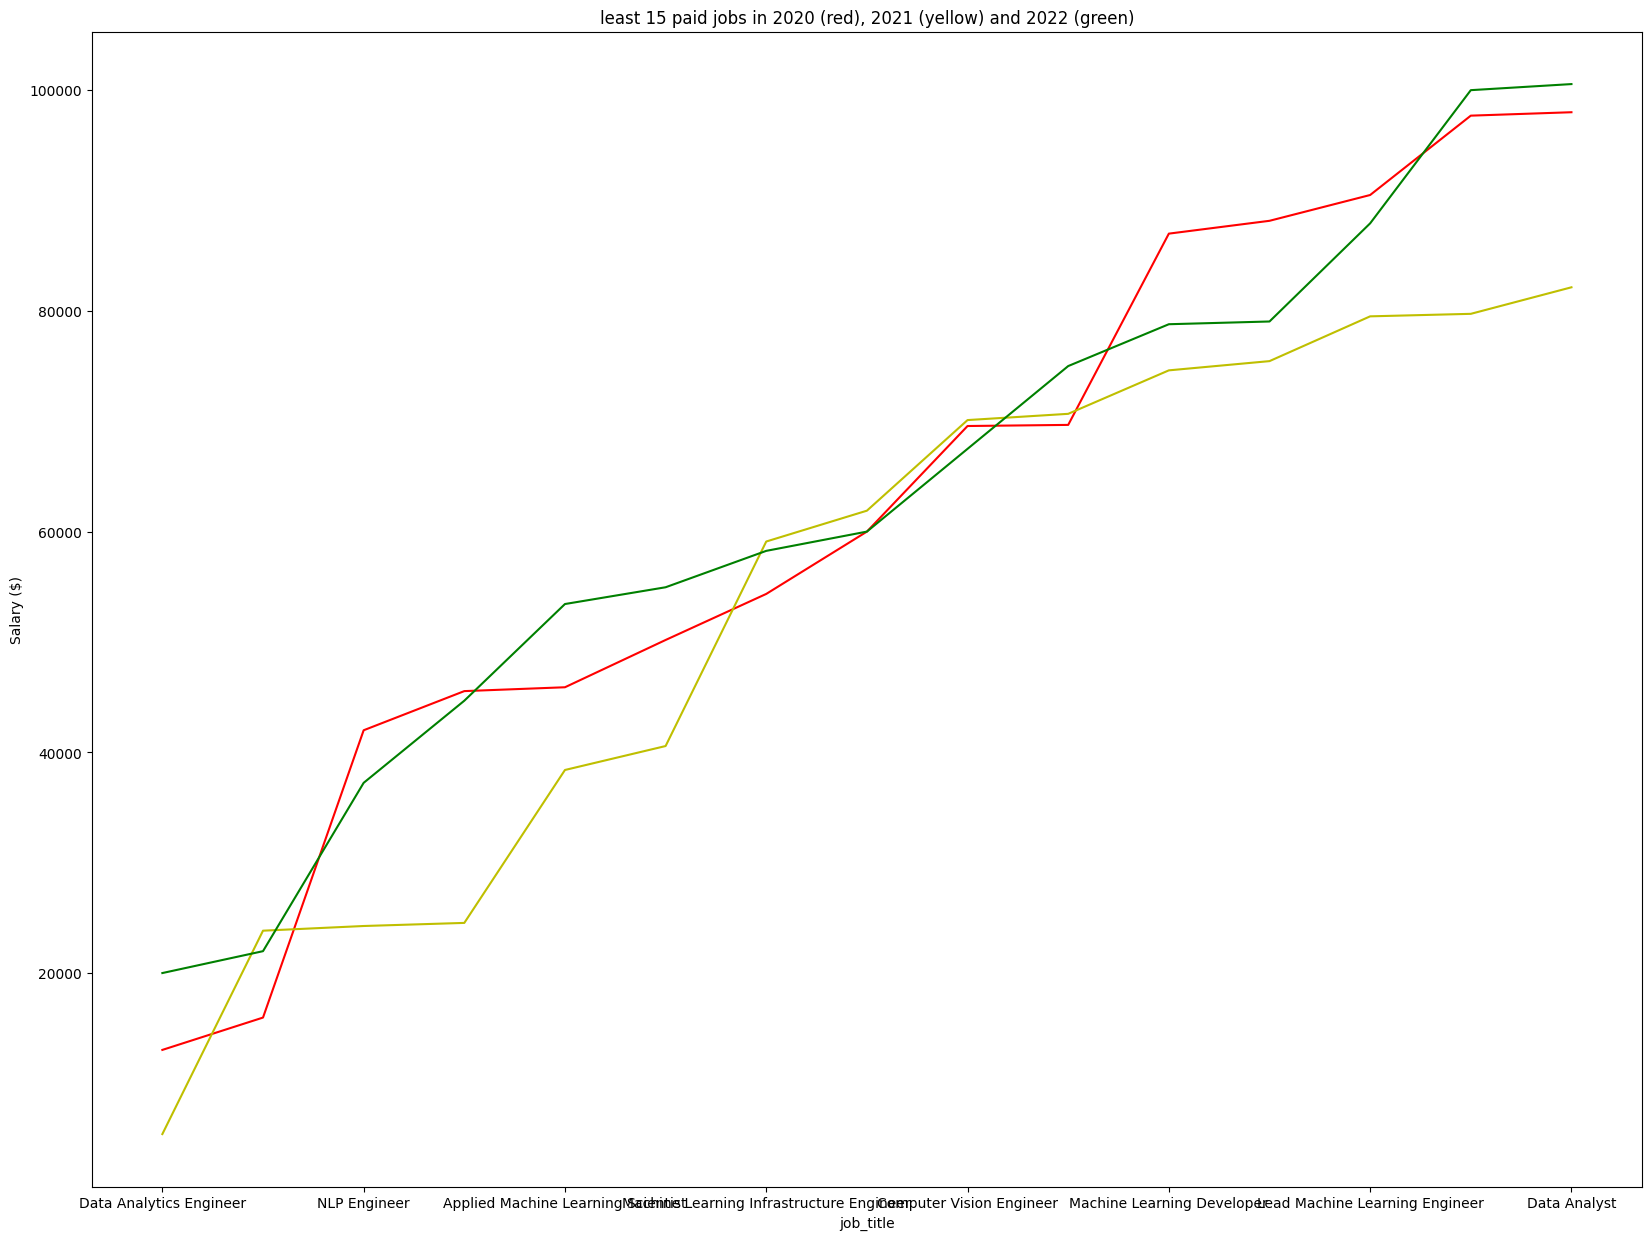

In [23]:
#least 15 paid jobs in 2020, 2021 and 2022 but is diffecalt to see it so we make anather graph to see it better
plt.figure(figsize = (20, 15))
df[df['work_year'] == 2020].groupby('job_title')['salary_in_usd'].mean().sort_values(ascending = True).head(15).plot.line(color = 'r')
df[df['work_year'] == 2021].groupby('job_title')['salary_in_usd'].mean().sort_values(ascending = True).head(15).plot.line(color = 'y')
df[df['work_year'] == 2022].groupby('job_title')['salary_in_usd'].mean().sort_values(ascending = True).head(15).plot.line(color = 'g')
plt.ylabel('Salary ($)')
plt.title('least 15 paid jobs in 2020 (red), 2021 (yellow) and 2022 (green)')

In [24]:
years = sorted(df['work_year'].unique())
fig = go.Figure()

for i, year in enumerate(years):
    temp = df[df['work_year'] == year].groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=True).head(15)
    fig.add_trace(go.Bar(
        x=temp.index,
        y=temp.values,
        name=str(year),
        visible=(i == 0)
    ))

buttons = []
for i, year in enumerate(years):
    visible = [j == i for j in range(len(years))]
    buttons.append(dict(
        label=str(year),
        method='update',
        args=[
            {'visible': visible},
            {'title': f'least 15 paid jobs in {year}'}
        ]
    ))

fig.update_layout(
    title=f'least 15 paid jobs in {years[0]}',
    xaxis_title='Job Title',
    yaxis_title='Salary ($)',
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            x=0.0,
            y=1.15,
            xanchor='left',
            yanchor='top'
        )
    ]
)

fig.show()

Text(0.5, 0, 'salary')

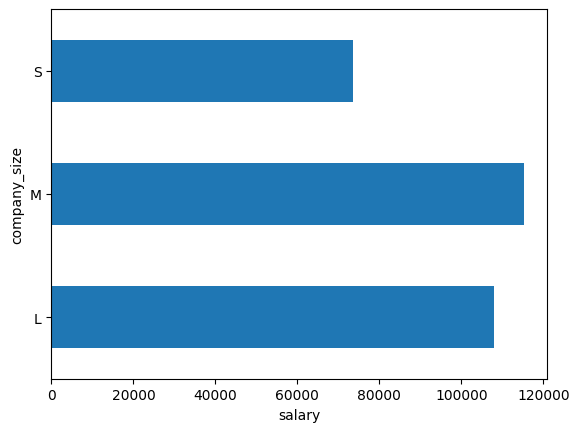

In [25]:
#average salary by company size
df.groupby('company_size')['salary_in_usd'].mean().plot(kind = 'barh')
plt.xlabel('salary')

In [26]:
#average salary by company size and job title
temp = df.pivot_table(values="salary_in_usd",
                    index='job_title',
                    columns="company_size")
temp = temp.fillna(0).round(0).astype(int)
temp.style.background_gradient(cmap='Reds')

company_size,L,M,S
job_title,,,
3D Computer Vision Researcher,0,5409,0
AI Scientist,127500,66000,25316
Analytics Engineer,0,175000,0
Applied Data Scientist,124569,0,0
Applied Machine Learning Scientist,75000,35138,0
BI Data Analyst,93130,99000,32136
Big Data Architect,0,99703,0
Big Data Engineer,28680,84512,66024
Business Data Analyst,91254,18442,0


In [27]:
temp = df.groupby('job_title')['salary_in_usd'].mean().to_frame().sort_values(by='salary_in_usd', ascending=False)
temp = temp.reset_index()

temp.head(10)

,job_title,salary_in_usd
0,Principal Data Engineer,192500.000000
1,Principal Data Scientist,181782.833333
2,Data Architect,177873.909091
3,Analytics Engineer,175000.000000
4,Director of Data Science,173419.666667
5,Data Specialist,165000.000000
6,Head of Data,160162.600000
7,Machine Learning Scientist,158412.500000
8,Data Science Manager,158328.500000
9,Director of Data Engineering,156738.000000


In [28]:
#mean Salary For Each Job
fig1 = go.Figure()
# IN big drawing Confirmed
fig1.add_trace(go.Scatter( x = temp['job_title'], y = temp['salary_in_usd'],
                         name = "Confirmed",
                         line_color = 'deepskyblue',
                         opacity = 0.8               #gana line
                        ))

fig1.update_layout(title_text = 'Mean Salary For Each Job')
fig.show()

Text(0.5, 1.0, 'Most Common Jobs Across All Company Sizes')

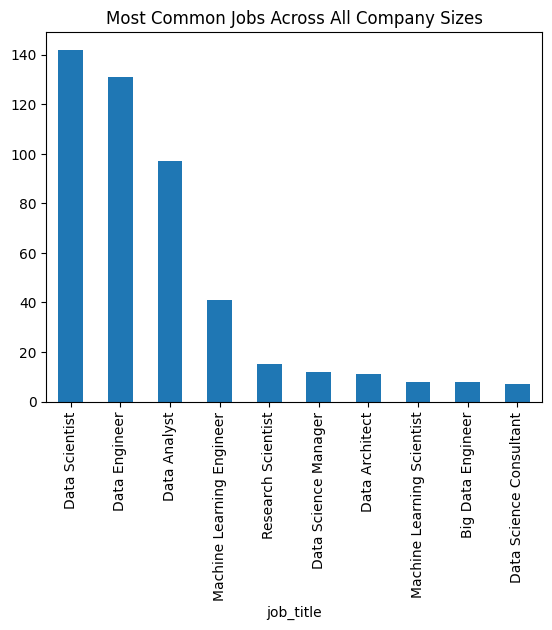

In [29]:
#Most Common Jobs Across All Company Sizes
df['job_title'].value_counts().head(10).plot(kind='bar')
plt.title('Most Common Jobs Across All Company Sizes')

Text(0.5, 1.0, 'Data we have for company sizes')

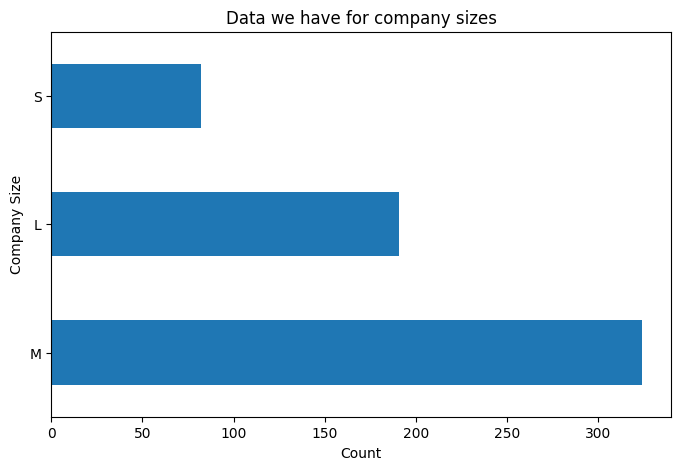

In [30]:
#Data we have for company sizes
plt.figure(figsize = (8, 5))
df['company_size'].value_counts().plot(kind = 'barh')
plt.ylabel('Company Size')
plt.xlabel('Count')
plt.title('Data we have for company sizes')

In [31]:
df['experience_level'].unique()

<StringArray>
['MI', 'SE', 'EN', 'EX']
Length: 4, dtype: str

In [32]:
df.loc[df['employment_type'] == 'FL', 'employment_type'] = 'FT'

###### On Average, how much a company size affects its salary payments

Text(0.5, 1.0, 'Average Salary Against Company Size for year 2020')

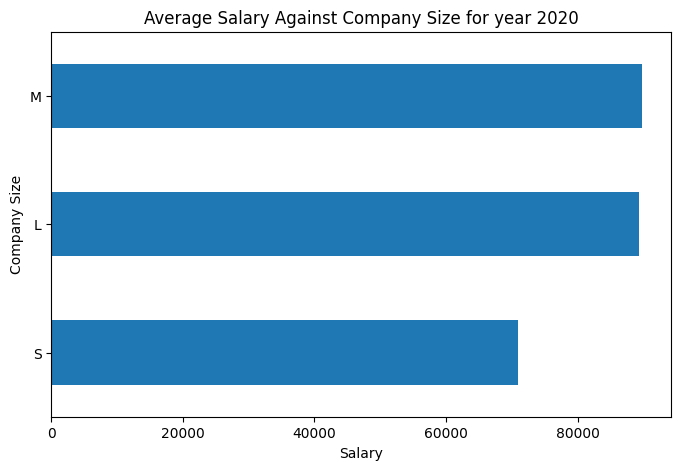

In [33]:
plt.figure(figsize = (8, 5))
df[df['work_year'] == 2020].groupby('company_size')['salary_in_usd'].mean().sort_values().plot(kind = 'barh')
plt.xlabel('Salary')
plt.ylabel('Company Size')
plt.title('Average Salary Against Company Size for year 2020')

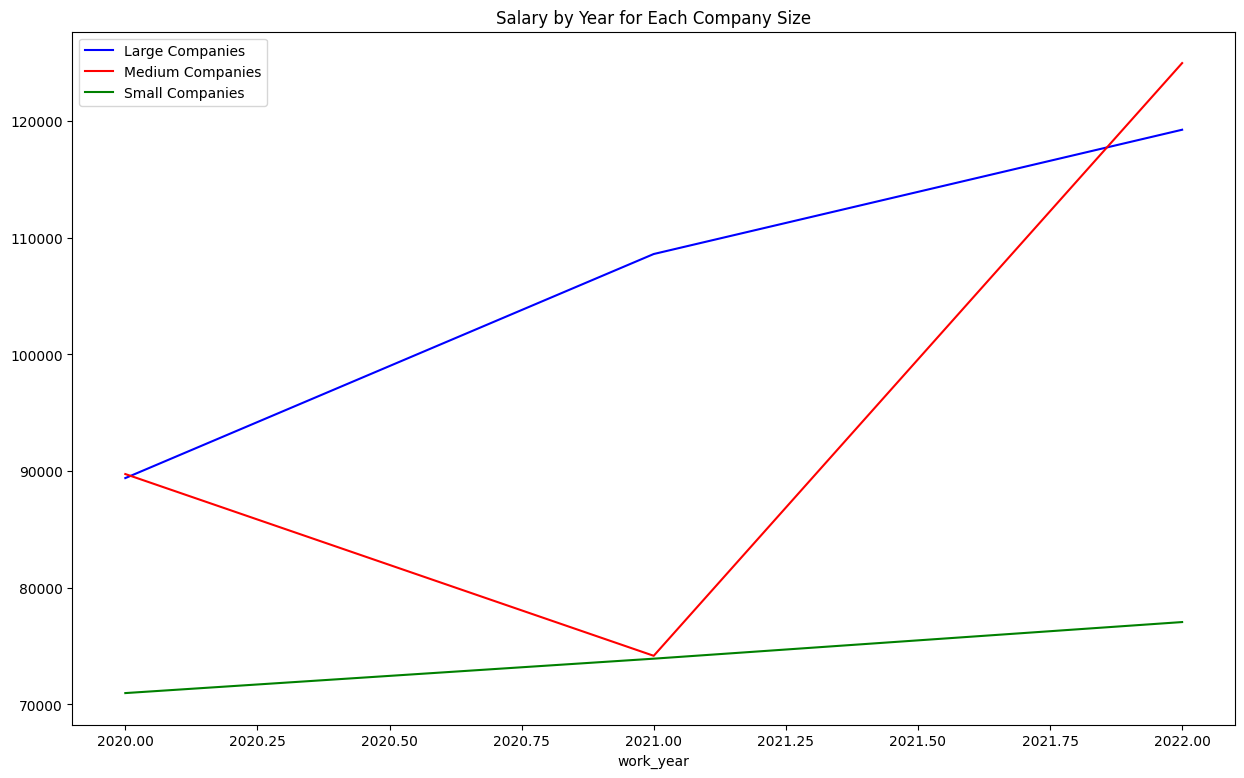

In [34]:
plt.figure(figsize = (15, 9))
df[df['company_size'] == 'L'].groupby('work_year')['salary_in_usd'].mean().plot.line(color = 'b', label = 'Large Companies')
df[df['company_size'] == 'M'].groupby('work_year')['salary_in_usd'].mean().plot.line(color = 'r', label = 'Medium Companies')
df[df['company_size'] == 'S'].groupby('work_year')['salary_in_usd'].mean().plot.line(color = 'g', label = 'Small Companies')
plt.title('Salary by Year for Each Company Size')
plt.legend()

In [35]:
df[df['company_size'] == 'S']['employment_type'].unique()

<StringArray>
['FT', 'PT']
Length: 2, dtype: str

In [36]:
df[df['company_size'] == 'M']['employment_type'].unique()

<StringArray>
['FT', 'PT', 'CT']
Length: 3, dtype: str

In [37]:
df[df['company_size'] == 'L']['employment_type'].unique()

<StringArray>
['FT', 'CT', 'PT']
Length: 3, dtype: str

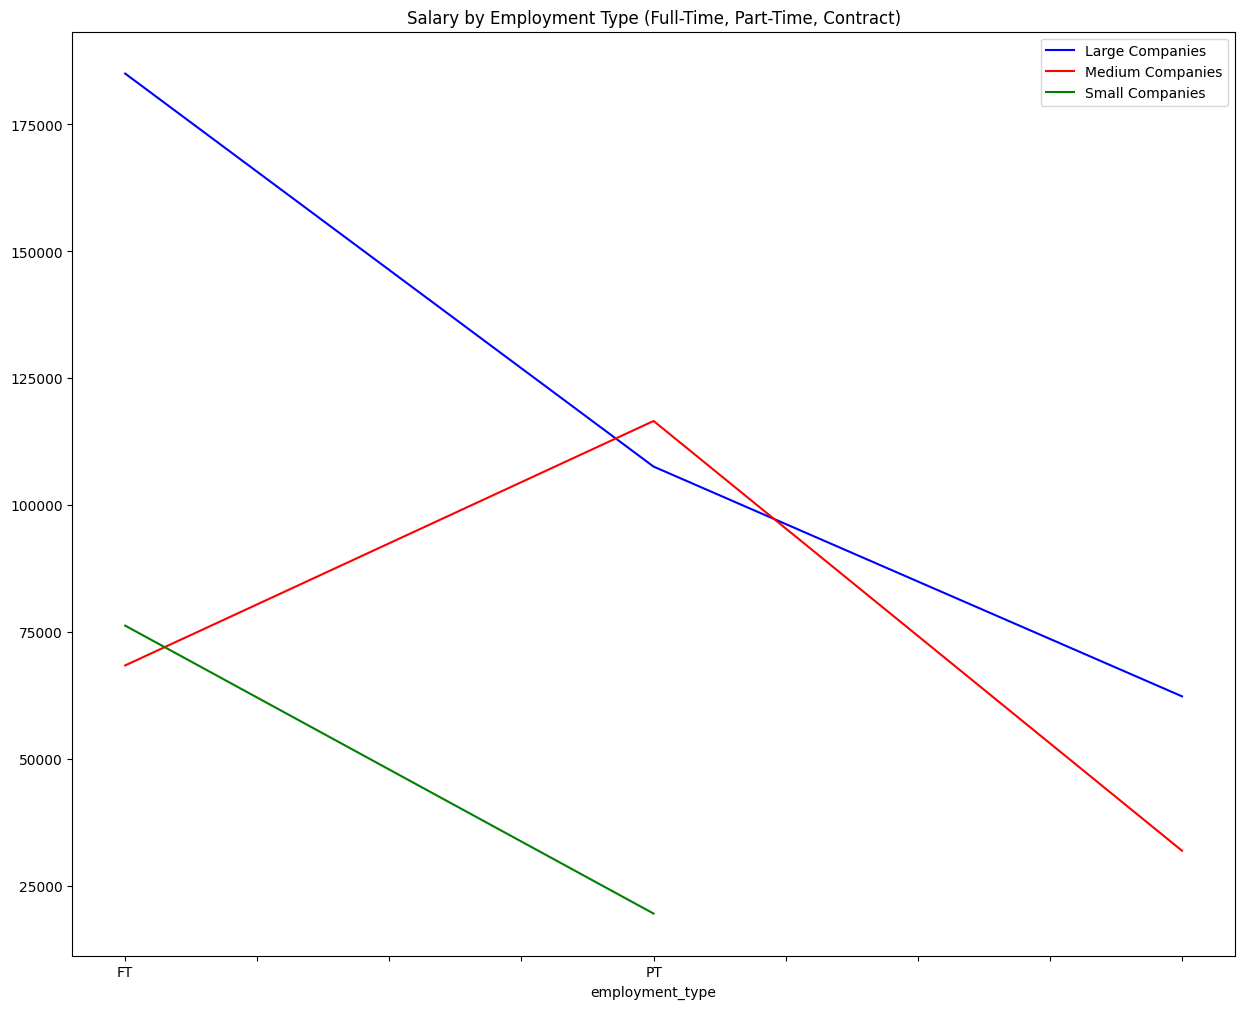

In [38]:
#Salary by Employment Type (Full-Time, Part-Time, Contract)
plt.figure(figsize = (15, 12))
df[df['company_size'] == 'L'].groupby('employment_type')['salary_in_usd'].mean().plot.line(color = 'b', label = 'Large Companies')
df[df['company_size'] == 'M'].groupby('employment_type')['salary_in_usd'].mean().plot.line(color = 'r', label = 'Medium Companies')
df[df['company_size'] == 'S'].groupby('employment_type')['salary_in_usd'].mean().plot.line(color = 'g', label = 'Small Companies')
plt.title('Salary by Employment Type (Full-Time, Part-Time, Contract)')
plt.legend()

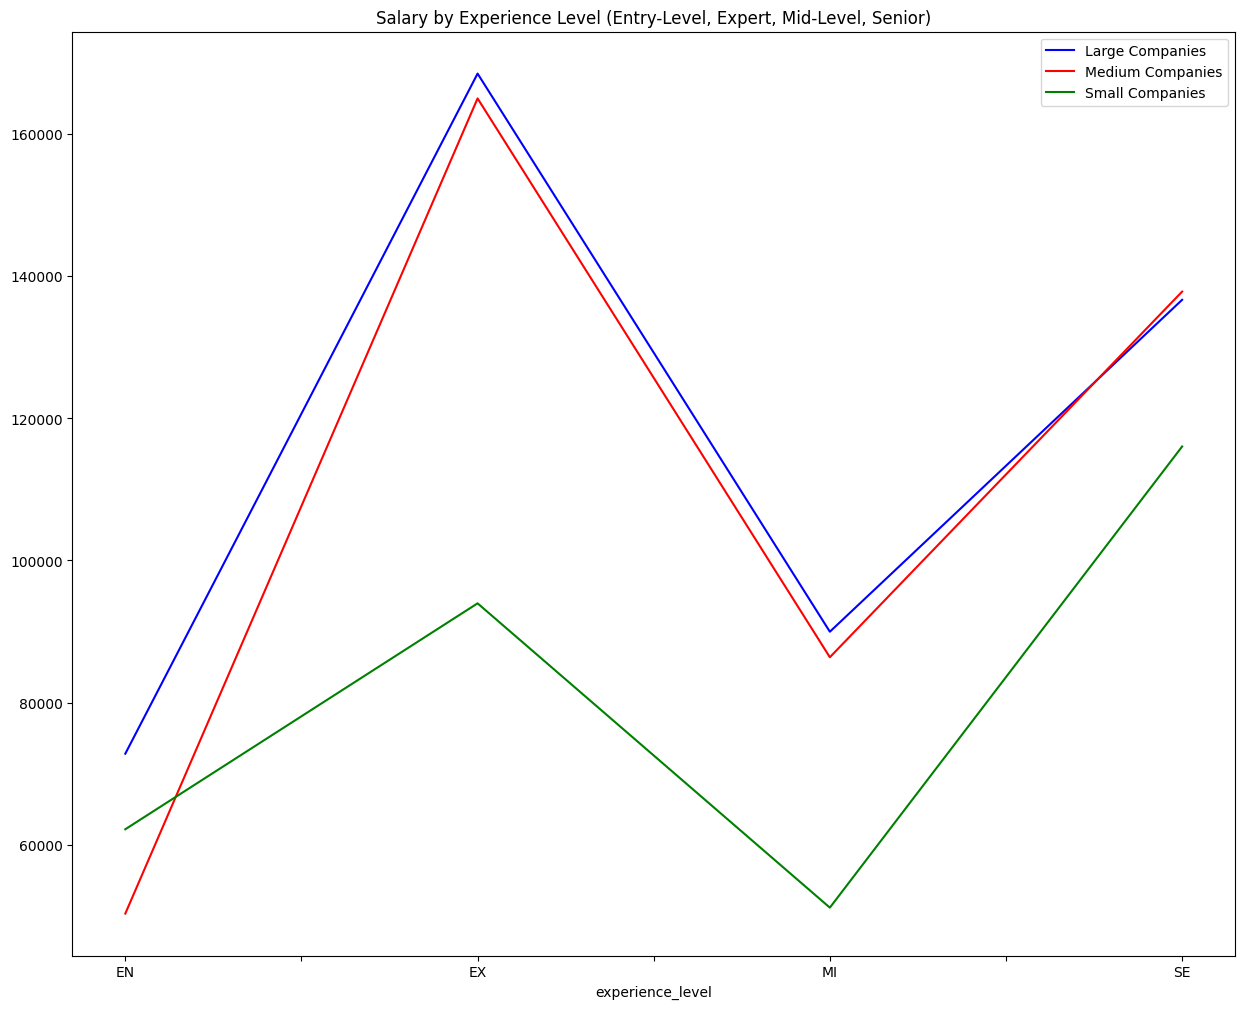

In [39]:
plt.figure(figsize = (15, 12))
df[df['company_size'] == 'L'].groupby('experience_level')['salary_in_usd'].mean().plot.line(color = 'b', label = 'Large Companies')
df[df['company_size'] == 'M'].groupby('experience_level')['salary_in_usd'].mean().plot.line(color = 'r', label = 'Medium Companies')
df[df['company_size'] == 'S'].groupby('experience_level')['salary_in_usd'].mean().plot.line(color = 'g', label = 'Small Companies')
plt.title('Salary by Experience Level (Entry-Level, Expert, Mid-Level, Senior)')
plt.legend()

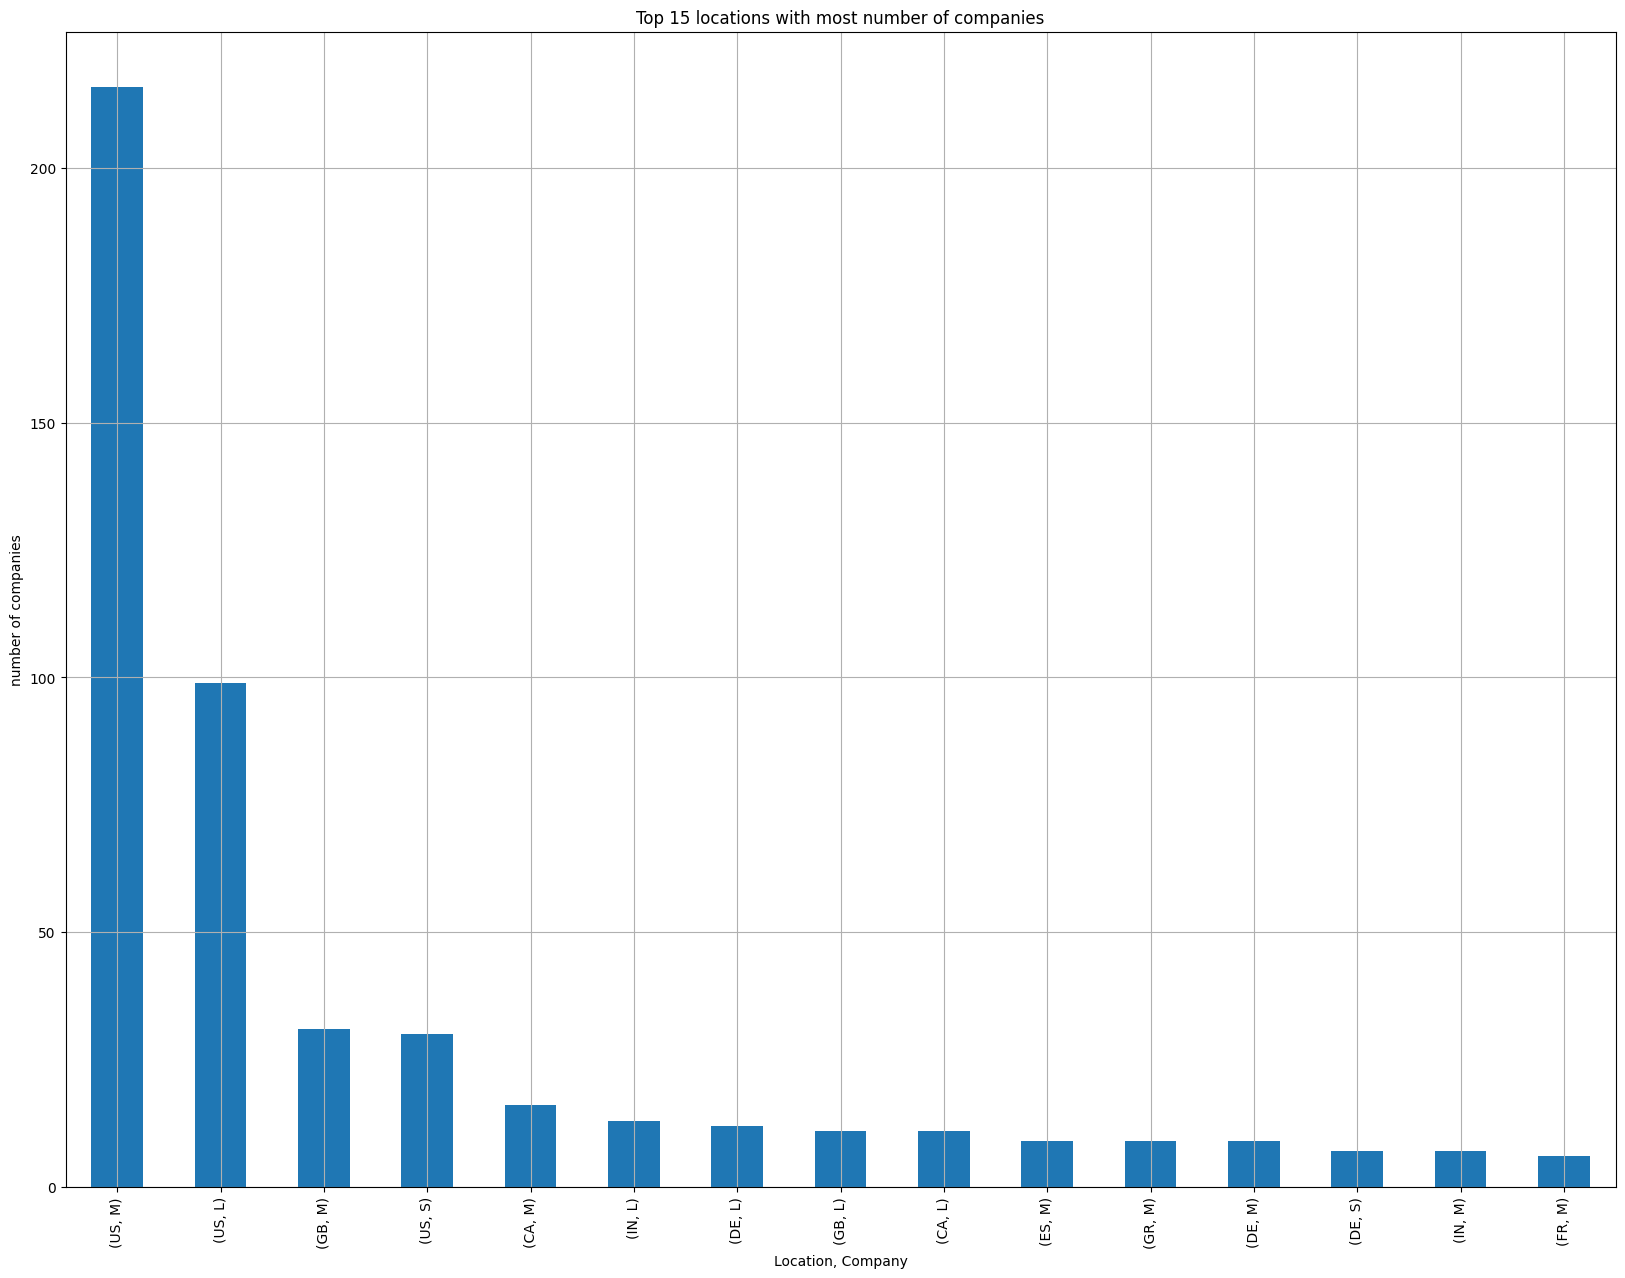

In [40]:
plt.figure(figsize = (20, 15))
df.groupby('company_location')[['company_size']].value_counts().sort_values(ascending = False).head(15).plot.bar()
plt.xlabel('Location, Company')
plt.ylabel('number of companies')
plt.title('Top 15 locations with most number of companies')
plt.grid()

## Data Preprocessing for ML Model

###### Label Encoding features to include in ML model

In [41]:
le = LabelEncoder()
for x in df.select_dtypes(include='object').columns.tolist():
    df[x] = le.fit_transform(df[x])

C:\Users\saif\AppData\Local\Temp\ipykernel_22012\3245738892.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for x in df.select_dtypes(include='object').columns.tolist():


In [42]:
df['Emp_Comp_Loc'] = (df['employee_residence'] == df['company_location']).astype(int)
#### or ####
#df['Emp_Comp_Loc'] = (df['employee_residence'] == df['company_location'])
#df.loc[df['Emp_Comp_Loc'] == True, 'Emp_Comp_Loc'] = 1
#df.loc[df['Emp_Comp_Loc'] == False, 'Emp_Comp_Loc'] = 0

In [43]:
x = df.drop(columns = ['Unnamed: 0', 'salary', 'salary_currency', 'salary_in_usd'])
y = df['salary_in_usd']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [44]:
pca = PCA(n_components = 2)
data_pca = pca.fit_transform(x)

C:\Users\saif\AppData\Local\Temp\ipykernel_22012\2011426784.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_pca[:, 0], data_pca[:, 1], cmap = 'rainbow', marker = 'o', s = 50)


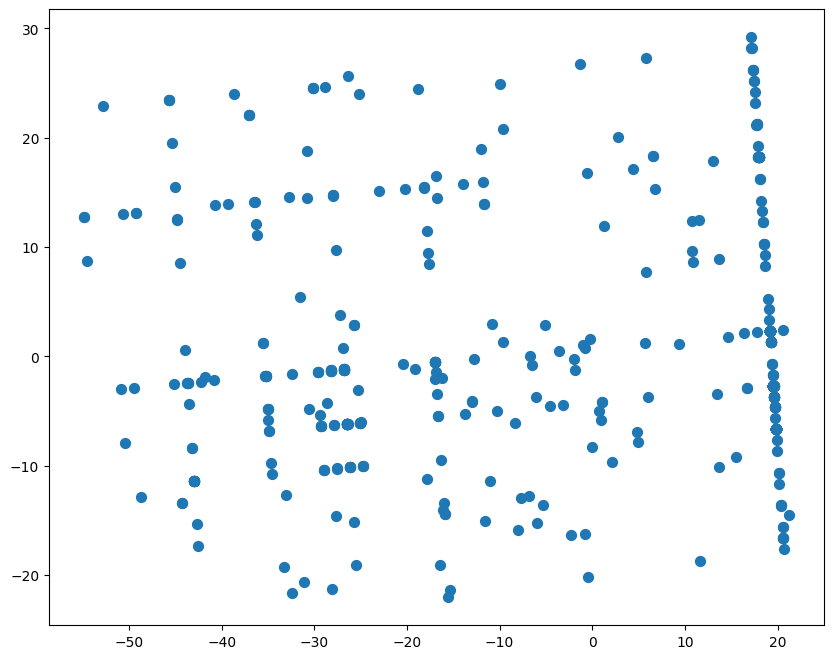

In [45]:
plt.figure(figsize = (10, 8))
plt.scatter(data_pca[:, 0], data_pca[:, 1], cmap = 'rainbow', marker = 'o', s = 50)

In [46]:
RF_Regressor = RandomForestRegressor(n_estimators = 100, random_state = 42)
RF_Regressor.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [47]:
y_pred = RF_Regressor.predict(x_test)

In [48]:
r2 = r2_score(y_test, y_pred)
r2

0.4662239717786224

In [49]:
y_test_pred = RF_Regressor.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mse

1618513643.734932